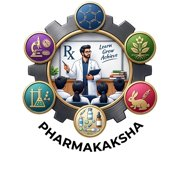

# BP801T · Unit III — AI in Pharmacy Automation and Supply Chain
**Pharmakaksha · Learn · Grow · Achieve**
*Ethical Considerations and Translational Applications of AI in Pharmacy · B.Pharm Semester VIII · PCI NEP 2020*

This notebook contains every example and demo from the Unit III study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit3_Pharmacy_Automation_and_Supply_Chain.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit3_Pharmacy_Automation_and_Supply_Chain.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The models are for learning only. They are not clinical, regulatory or legal tools.

## 3.1 Automated dispensing
Automated dispensing cabinets and robots pick medicines by **barcode**, not by eye. The core safety check is simple: the scanned pack must match the prescription.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

TEAL, GREEN, ORANGE, GREY = "#12303A", "#1F8A70", "#E07A2E", "#8A9BA3"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def verify_pick(prescribed, scanned):
    """Barcode check before a pack leaves the robot."""
    if scanned == prescribed:
        return "OK — release"
    return f"STOP — scanned {scanned}, prescribed {prescribed}"

print(verify_pick("8901234-AMLO-5MG", "8901234-AMLO-5MG"))
print(verify_pick("8901234-AMLO-5MG", "8901234-AMLO-10MG"))

Did automation reduce errors? `dispensing_log.csv` counts dispensing errors in a hospital pharmacy before (manual, 2024) and after (automated, 2025).

In [ ]:
log = load("dispensing_log.csv")
print(log.to_string(index=False))

summary = log.pivot_table(index="system", columns="category", values="count", aggfunc="sum")
summary["Errors"] = summary[["Wrong drug", "Wrong strength", "Wrong quantity"]].sum(axis=1)
summary["Errors per 10,000"] = (10000 * summary["Errors"] / summary["Total prescriptions"]).round(1)
print()
print(summary[["Total prescriptions", "Errors", "Errors per 10,000"]])

In [ ]:
from scipy.stats import chi2_contingency

table = [[summary.loc[s, "Errors"], summary.loc[s, "Total prescriptions"] - summary.loc[s, "Errors"]]
         for s in ["Manual", "Automated"]]
chi2, p, dof, _ = chi2_contingency(table)
print(f"Chi-square = {chi2:.2f}, p = {p:.4f}")

Errors fell from about 28 to 10 per 10,000 prescriptions, and the chi-square test says the drop is unlikely to be chance (p < 0.05). This is a before–after study, so other changes in 2025 may also have helped.

## 3.2 Regression-based demand forecasting — case study
`pharmacy_demand.csv` holds four years (2022–2025) of weekly sales for three products in a fictional chain of pharmacies. Look at the seasons first.

In [ ]:
demand = load("pharmacy_demand.csv")
demand["week_start"] = pd.to_datetime(demand["week_start"])
print(demand.groupby("product")["units_sold"].describe()[["mean", "min", "max"]].round(0))

fig, ax = plt.subplots(figsize=(10, 4))
for prod, colour in zip(demand["product"].unique(), [ORANGE, GREEN, TEAL]):
    s = demand[demand["product"] == prod]
    ax.plot(s["week_start"], s["units_sold"], color=colour, linewidth=1.2, label=prod)
ax.set_ylabel("Units sold per week"); ax.legend(fontsize=8)
ax.set_title("Seasonal demand: monsoon fevers, summer dehydration, spring allergies")
plt.tight_layout(); plt.show()

We forecast **Paracetamol 650 mg** with a linear regression. The features are a **trend** (week number), **month dummies** for the season, a **promotion** flag and a **festival-week** flag. We train on 2022–2024 and test on 2025.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape

para = demand[demand["product"].str.startswith("Paracetamol")].copy().reset_index(drop=True)
para["t"] = np.arange(len(para))
para["month"] = para["week_start"].dt.month
Xp = pd.get_dummies(para[["t", "promotion", "festival_week", "month"]], columns=["month"], drop_first=True, dtype=int)
train, test = para["week_start"].dt.year <= 2024, para["week_start"].dt.year == 2025

reg = LinearRegression().fit(Xp[train], para.loc[train, "units_sold"])
para.loc[test, "forecast"] = reg.predict(Xp[test])

# Naive forecast for comparison: same week last year
para["naive"] = para["units_sold"].shift(52)
y25 = para.loc[test, "units_sold"]
print(f"Regression MAPE        = {mape(y25, para.loc[test, 'forecast']):.1%}")
print(f"Naive (last year) MAPE = {mape(y25, para.loc[test, 'naive']):.1%}")
print(f"Trend: +{reg.coef_[0]:.2f} strips per week, i.e. about {52 * reg.coef_[0]:.0f} more per week each year")

In [ ]:
t25 = para[test]
plt.figure(figsize=(10, 4))
plt.plot(t25["week_start"], t25["units_sold"], color=TEAL, label="Actual 2025")
plt.plot(t25["week_start"], t25["forecast"], color=ORANGE, linestyle="--", label="Regression forecast")
plt.plot(t25["week_start"], t25["naive"], color=GREY, linewidth=1, label="Naive (last year)")
plt.ylabel("Strips per week"); plt.legend()
plt.title("Paracetamol 650 mg — 2025 forecast vs actual")
plt.tight_layout(); plt.show()

**MAPE** (mean absolute percentage error) is the average forecast miss in percent. The regression beats the naive method because it captures both the season **and** the growth trend.

## 3.3 Inventory prediction — safety stock and reorder point
A forecast is never exact, so we hold **safety stock** for the forecast error during the supplier's lead time.

- Safety stock = z × σ(error) × √(lead time in weeks), with z = 1.65 for a 95% service level
- Reorder point = forecast demand during the lead time + safety stock

In [ ]:
sigma = (y25 - para.loc[test, "forecast"]).std()
lead_weeks, z = 2, 1.65
next_weeks = para.loc[test, "forecast"].tail(lead_weeks)
safety = z * sigma * np.sqrt(lead_weeks)
reorder_point = next_weeks.sum() + safety
print(f"Forecast error SD      = {sigma:.0f} strips/week")
print(f"Safety stock           = {safety:.0f} strips")
print(f"Reorder point          = {reorder_point:.0f} strips (order when stock falls to this level)")

## 3.4 Adherence monitoring
**Proportion of days covered (PDC)** = days on which the patient had medicine ÷ days in the period. PDC ≥ 0.80 is the usual cut-off for **adherent**.
`refill_records.csv` has every 30-day refill in 2025 for 500 patients on chronic medicines.

In [ ]:
refills = load("refill_records.csv")
refills["fill_date"] = pd.to_datetime(refills["fill_date"])
print(refills.head(4))

def pdc(group, start="2025-01-01", end="2025-12-31"):
    days = pd.date_range(start, end)
    covered = np.zeros(len(days), dtype=bool)
    for _, r in group.iterrows():
        i = (r["fill_date"] - pd.Timestamp(start)).days
        covered[i:i + r["days_supply"]] = True
    return covered.mean()

pdc_scores = refills.groupby("patient_id").apply(pdc, include_groups=False).rename("pdc")
print(f"\nMedian PDC = {pdc_scores.median():.2f};  adherent (PDC >= 0.80): {(pdc_scores >= 0.8).mean():.0%} of patients")

In [ ]:
plt.hist(pdc_scores, bins=25, color=GREEN, edgecolor="white")
plt.axvline(0.8, color=ORANGE, linestyle="--", linewidth=2, label="Cut-off 0.80")
plt.xlabel("Proportion of days covered (2025)"); plt.ylabel("Patients"); plt.legend()
plt.title("Medication adherence from refill records")
plt.tight_layout(); plt.show()

**Predicting non-adherence.** If we can predict who will fall below 0.80, the pharmacist can call those patients first. We join the PDC to patient features and fit a logistic regression.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
import statsmodels.api as sm

pts = load("adherence_patients.csv").merge(pdc_scores, left_on="patient_id", right_index=True)
pts["non_adherent"] = (pts["pdc"] < 0.8).astype(int)
pts["copay_100rs"] = pts["copay_rs"] / 100          # odds ratio per Rs 100
feats = ["age", "n_chronic_meds", "distance_km", "copay_100rs", "sms_reminder", "prior_gap"]
cvs = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()), pts[feats], pts["non_adherent"],
                      cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc")
print(f"Non-adherent: {pts['non_adherent'].mean():.0%}   5-fold AUC = {cvs.mean():.2f}")
fit = sm.Logit(pts["non_adherent"], sm.add_constant(pts[feats])).fit(disp=0)
print(np.exp(fit.params).drop("const").round(2).rename("odds ratio"))

Reading the odds ratios: **SMS reminders** cut the odds of non-adherence by about three-quarters (OR 0.26). A **past refill gap** raises them about six-fold, every extra **Rs 100 co-payment** roughly doubles them, and each extra **medicine** (1.18) and **kilometre** of travel (1.06) adds a little. Most of these are **actionable**: extend reminders, offer home delivery to distant patients, and review co-payments.

## 3.5 Supply-chain risk prediction
`supplier_shipments.csv` lists 800 past deliveries to a hospital pharmacy, with whether each arrived late.

In [ ]:
ship = load("supplier_shipments.csv")
print(f"Delayed shipments: {ship['delayed'].mean():.0%}")
print(ship.groupby("supplier")[["supplier_rating", "delayed"]].mean().round(2))

In [ ]:
ship["import"] = (ship["origin"] == "Import").astype(int)
sfeats = ["supplier_rating", "import", "distance_km", "monsoon", "cold_chain"]
risk_model = make_pipeline(StandardScaler(), LogisticRegression()).fit(ship[sfeats], ship["delayed"])
auc = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()), ship[sfeats], ship["delayed"],
                      cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc").mean()
print(f"5-fold AUC = {auc:.2f}")

upcoming = pd.DataFrame({
    "order": ["Insulin (cold chain), import, July", "Paracetamol, domestic, January", "Oncology injectable, S5, monsoon"],
    "supplier_rating": [4.2, 4.6, 3.0], "import": [1, 0, 1], "distance_km": [3600, 400, 3900],
    "monsoon": [1, 0, 1], "cold_chain": [1, 0, 1]})
upcoming["delay_risk"] = risk_model.predict_proba(upcoming[sfeats])[:, 1].round(2)
print(upcoming[["order", "delay_risk"]].to_string(index=False))

High-risk orders can be placed earlier, split between suppliers, or backed by buffer stock.

## 3.6 Logistics analytics
Descriptive analytics often answers the first questions: where and when are we late, and by how much?

In [ ]:
late = ship[ship["delayed"] == 1]
print("Average delay (days) when late, by origin and season:")
print(late.pivot_table(index="origin", columns="monsoon", values="delay_days", aggfunc="mean")
          .rename(columns={0: "Dry season", 1: "Monsoon"}).round(1))
print("\nDelay rate by origin and season:")
print(ship.pivot_table(index="origin", columns="monsoon", values="delayed", aggfunc="mean")
          .rename(columns={0: "Dry season", 1: "Monsoon"}).round(2))

## 3.7 Legal and privacy considerations
Pharmacy data is **personal data** (and health data is especially sensitive). In India the **Digital Personal Data Protection (DPDP) Act 2023** and the **DPDP Rules 2025** (notified 13 Nov 2025; most duties apply from 13 May 2027) require a clear purpose, notice and consent, security safeguards, breach reporting and deletion when the purpose is over.

Two technical safeguards:
1. **Pseudonymisation** — replace the patient ID with a code that cannot be reversed without a secret key.

In [ ]:
import hashlib

SECRET_SALT = "keep-this-secret-in-a-vault"   # never store it with the data
def pseudonymise(pid):
    return hashlib.sha256((SECRET_SALT + pid).encode()).hexdigest()[:12]

shared = pts[["patient_id", "age", "pin_code", "pdc"]].head(3).copy()
shared["pseudo_id"] = shared["patient_id"].apply(pseudonymise)
print(shared.drop(columns="patient_id").to_string(index=False))

2. **k-anonymity** — every combination of quasi-identifiers (age, PIN code …) should match at least *k* people, so nobody can be singled out. Exact age + PIN code fails; 10-year age bands + the first three PIN digits pass.

In [ ]:
def smallest_group(df, cols):
    return df.groupby(cols).size().min()

pts["age_band"] = (pts["age"] // 10 * 10).astype(str) + "s"
pts["pin3"] = pts["pin_code"].astype(str).str[:3] + "xxx"
print("Exact age + full PIN : smallest group =", smallest_group(pts, ["age", "pin_code"]))
print("Age band + 3-digit PIN: smallest group =", smallest_group(pts, ["age_band", "pin3"]))

**Other legal points for pharmacy automation:** a registered pharmacist remains responsible for every dispensed medicine (Pharmacy Practice Regulations 2015); automated records must be complete and auditable; and AI vendors who process patient data are **data processors** who must be bound by contract.

## Quick check
A forecasting model has a MAPE of 4% on its **training** weeks and 25% on the 2025 test weeks. Which number should go into the safety-stock calculation? Decide, then run the cell.

In [ ]:
print("The test-period error (25%): safety stock must cover the errors the model makes on new weeks.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Repeat the regression forecast for **ORS sachets**. Report the 2025 MAPE.

**2.** Recalculate the Paracetamol safety stock for a 99% service level (z = 2.33) and a 3-week lead time.

**3.** What share of patients **with** and **without** SMS reminders were adherent (PDC ≥ 0.80)?

**4.** Which supplier has the highest delay rate during the monsoon?

---
## Solutions

In [ ]:
# 1
ors = demand[demand["product"] == "ORS sachets"].copy().reset_index(drop=True)
ors["t"] = np.arange(len(ors)); ors["month"] = ors["week_start"].dt.month
Xo = pd.get_dummies(ors[["t", "promotion", "festival_week", "month"]], columns=["month"], drop_first=True, dtype=int)
tr, te = ors["week_start"].dt.year <= 2024, ors["week_start"].dt.year == 2025
m = LinearRegression().fit(Xo[tr], ors.loc[tr, "units_sold"])
print(f"ORS 2025 MAPE = {mape(ors.loc[te, 'units_sold'], m.predict(Xo[te])):.1%}")

In [ ]:
# 2
safety99 = 2.33 * sigma * np.sqrt(3)
print(f"Safety stock (99%, 3 weeks) = {safety99:.0f} strips")

In [ ]:
# 3
print(pts.groupby("sms_reminder")["pdc"].apply(lambda s: (s >= 0.8).mean()).round(2))

In [ ]:
# 4
print(ship[ship["monsoon"] == 1].groupby("supplier")["delayed"].mean().round(2).sort_values(ascending=False))

---
**Next:** Unit IV — AI in Public Health and Real-World Data. Pharmakaksha · Learn · Grow · Achieve